In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import pandas as pd 
import time

from scipy.ndimage import binary_dilation, binary_erosion
from skimage.morphology import opening, closing, area_closing, area_opening
from skimage.morphology import disk

from skimage.measure import label, regionprops, regionprops_table

# Feature Extraction

In [2]:
def rgb2gray(rgb):

    r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b   # calibrated for contemporary CRT phosphors

    return gray


'''
args: arraylike image
out: r,g,b values in Normalized Chromaticity Space (NCC) 

you then build a scotter plot of r (x-axis) and g (y-axis) where
the location of b is implied since  r + g + b = 1

'''
def NCC(image):   # we convert from RGB space to NCC space (r,g, and an extra b)
    R = image[:,:,0]
    G = image[:,:,1]
    B = image[:,:,2]
    
    I = R + G + B
    
    # now we calculate histograms
    r = np.divide(R, I, out=np.zeros_like(R), where=I!=0)  # if division by zero, pass out 0
    g = np.divide(G, I, out=np.zeros_like(G), where=I!=0)  # we divide here R,G,B / I
    b = np.divide(B, I, out=np.zeros_like(B), where=I!=0)  # we only have 1 pixel with this error so yea

    return r, g, b    # r g b in NCC space of pixels, these are lists

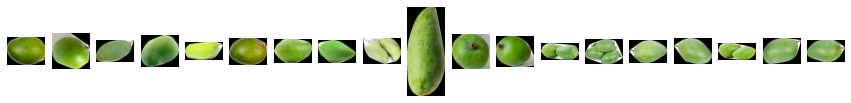

In [3]:
raw = Image.open('Inputs/raw2.png')
raw_array = np.array(raw) / 255
raw_GS = np.array(raw.convert('L'))

threshold = 200
raw_segmented_binary =  np.invert(cv2.threshold(raw_GS, threshold, 255, cv2.THRESH_BINARY)[1])
# plt.imshow(raw_segmented_binary, cmap='gray')
strel = disk(8)
raw_closed = closing(raw_segmented_binary, footprint=strel)
# plt.imshow(raw_closed, cmap='gray')

label_raw = label(raw_closed) # label pixels based on connectivity. count starts at upper right region

properties = ['area','bbox_area', 'extent',  
              'mean_intensity', 'solidity', 'eccentricity', 
              'orientation']

raw_measurement_table = pd.DataFrame(regionprops_table(label_raw, raw_GS, 
             properties=properties))

raw_measurement_table
raw_regions = regionprops(label_raw)

masks = []
bbox = []
list_of_index = []
for num, x in enumerate(raw_regions):
    area = x.area   
    convex_area = x.convex_area
    if (area>1000):    # filter out entries with area less than 6000, manually chosen
                                  # add more (and ____) to filter out more parameters
        masks.append(raw_regions[num].convex_image)
        bbox.append(raw_regions[num].bbox)   
        list_of_index.append(num)
raw_count = len(masks)


raw_good_measurements = raw_measurement_table.loc[list_of_index]  # regions that fit the area_threshold
raw_good_measurements

raw_avg_GS = []
raw_avg_r = []   # average r value in NCC space for each object
raw_avg_g = []   # average g value in NCC space for each object

fig, ax = plt.subplots(1, int(raw_count), figsize=(15,3))
for axis, box, mask in zip(ax.flatten(), bbox, masks):
    red  =  raw_array[:,:,0][box[0]:box[2], box[1]:box[3]] * mask
    green = raw_array[:,:,1][box[0]:box[2], box[1]:box[3]] * mask
    blue  = raw_array[:,:,2][box[0]:box[2], box[1]:box[3]] * mask
    raw_region_image = np.dstack([red,green,blue])
    
    # take average r and g of each region
    raw_curr_r_avg = np.mean(NCC(raw_region_image)[0])
    raw_curr_g_avg = np.mean(NCC(raw_region_image)[1])
    
    raw_avg_r.append(raw_curr_r_avg)
    raw_avg_g.append(raw_curr_g_avg)
    
    axis.imshow(raw_region_image)
    axis.axis('off')    # i can only display multiples of 2. In this case there are 19 objects but
                        # i could only show 18. Nevertheless, they are still accesible in good_measurements

# print(len(raw_avg_GS))  # average grayscale values


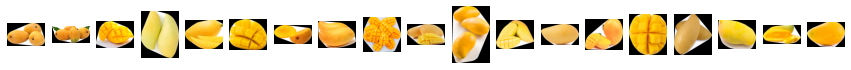

In [4]:
ripe = Image.open('Inputs/ripe2.png')
ripe_array = np.array(ripe) / 255
ripe_GS = np.array(ripe.convert('L'))

threshold = 220
ripe_segmented_binary =  np.invert(cv2.threshold(ripe_GS, threshold, 255, cv2.THRESH_BINARY)[1])
# plt.imshow(ripe_segmented_binary, cmap='gray')
strel = disk(8)
ripe_closed = closing(ripe_segmented_binary, footprint=strel)
# plt.imshow(ripe_closed, cmap='gray')

label_ripe = label(ripe_closed) # label pixels based on connectivity. count starts at upper right region

properties = ['area','bbox_area', 'extent',  
              'mean_intensity', 'solidity', 'eccentricity', 
              'orientation']

ripe_measurement_table = pd.DataFrame(regionprops_table(label_ripe, ripe_GS, 
             properties=properties))

ripe_measurement_table
ripe_regions = regionprops(label_ripe)

masks = []
bbox = []
list_of_index = []
for num, x in enumerate(ripe_regions):
    area = x.area   
    convex_area = x.convex_area
    if (area>1000):    # filter out entries with area less than 6000, manually chosen
                                  # add more (and ____) to filter out more parameters
        masks.append(ripe_regions[num].convex_image)
        bbox.append(ripe_regions[num].bbox)   
        list_of_index.append(num)
ripe_count = len(masks)


ripe_good_measurements = ripe_measurement_table.loc[list_of_index]  # regions that fit the area_threshold
ripe_good_measurements

ripe_avg_GS = []
ripe_avg_r = []   # average r value in NCC space for each object
ripe_avg_g = []   # average g value in NCC space for each object

fig, ax = plt.subplots(1, int(ripe_count), figsize=(15,3))
for axis, box, mask in zip(ax.flatten(), bbox, masks):
    red  =  ripe_array[:,:,0][box[0]:box[2], box[1]:box[3]] * mask
    green = ripe_array[:,:,1][box[0]:box[2], box[1]:box[3]] * mask
    blue  = ripe_array[:,:,2][box[0]:box[2], box[1]:box[3]] * mask
    ripe_region_image = np.dstack([red,green,blue])
    
    # take average r and g of each region
    ripe_curr_r_avg = np.mean(NCC(ripe_region_image)[0])
    ripe_curr_g_avg = np.mean(NCC(ripe_region_image)[1])
    
    ripe_avg_r.append(ripe_curr_r_avg)
    ripe_avg_g.append(ripe_curr_g_avg)
    
    axis.imshow(ripe_region_image)
    axis.axis('off')    # i can only display multiples of 2. In this case there are 19 objects but
                        # i could only show 18. Nevertheless, they are still accesible in good_measurements

# print(len(ripe_avg_GS))  # average grayscale values


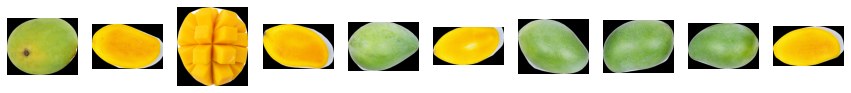

In [5]:
test = Image.open('Inputs/test.png')
test_array = np.array(test) / 255
test_GS = np.array(test.convert('L'))

threshold = 220
test_segmented_binary =  np.invert(cv2.threshold(test_GS, threshold, 255, cv2.THRESH_BINARY)[1])
# plt.imshow(test_segmented_binary, cmap='gray')
strel = disk(8)
test_closed = closing(test_segmented_binary, footprint=strel)
# plt.imshow(test_closed, cmap='gray')

label_test = label(test_closed) # label pixels based on connectivity. count starts at upper right region

properties = ['area','bbox_area', 'extent',  
              'mean_intensity', 'solidity', 'eccentricity', 
              'orientation']

test_measurement_table = pd.DataFrame(regionprops_table(label_test, test_GS, 
             properties=properties))

test_measurement_table
test_regions = regionprops(label_test)

masks = []
bbox = []
list_of_index = []
for num, x in enumerate(test_regions):
    area = x.area   
    convex_area = x.convex_area
    if (area>1000):    # filter out entries with area less than 6000, manually chosen
                                  # add more (and ____) to filter out more parameters
        masks.append(test_regions[num].convex_image)
        bbox.append(test_regions[num].bbox)   
        list_of_index.append(num)
test_count = len(masks)


test_good_measurements = test_measurement_table.loc[list_of_index]  # regions that fit the area_threshold
test_good_measurements

test_avg_GS = []
test_avg_r = []   # average r value in NCC space for each object
test_avg_g = []   # average g value in NCC space for each object

test_img_list = []   # this is later for plotting in the final cell
fig, ax = plt.subplots(1, int(test_count), figsize=(15,3))
for axis, box, mask in zip(ax.flatten(), bbox, masks):
    red  =  test_array[:,:,0][box[0]:box[2], box[1]:box[3]] * mask
    green = test_array[:,:,1][box[0]:box[2], box[1]:box[3]] * mask
    blue  = test_array[:,:,2][box[0]:box[2], box[1]:box[3]] * mask
    test_region_image = np.dstack([red,green,blue])
    test_img_list.append(test_region_image)
    
    # take average r and g of each region
    test_curr_r_avg = np.mean(NCC(test_region_image)[0])
    test_curr_g_avg = np.mean(NCC(test_region_image)[1])
    
    test_avg_r.append(test_curr_r_avg)
    test_avg_g.append(test_curr_g_avg)
    
    axis.imshow(test_region_image)
    axis.axis('off')    
    
test_img_list = np.array(test_img_list, dtype='object')


(0.0, 1.0)

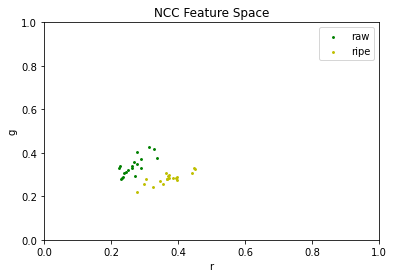

In [6]:
'''
Let's plot the feature space. In this example, it's the NCC space. 
'''

plt.scatter(raw_avg_r, raw_avg_g, color='g', label='raw', s=3.5)
plt.scatter(ripe_avg_r, ripe_avg_g, color='y', label='ripe', s=3.5)
plt.ylabel('g')
plt.xlabel('r')
plt.title('NCC Feature Space')
plt.legend()
plt.xlim(0,1)
plt.ylim(0,1)

# Logistic Regression 

In [7]:
'''
Logistric Regression that gives probabilities between two classes based on two features. 

Args: 
feature_matrix = N X 2 matrix of features, each row represents different objects while each column
                 represents a feature. Elememts must be normalized i.e. ranges from 0-1. There must
                 be a same number of objects per class, so the number of rows must be even.  Lastly,
                 the features of the same class must be in succeeding rows and not separated. 
                 
learning_rate = int, range from 0 to 1

sigmoid_rate = float, controls steepness of sigmoid threshold

constant_bias = int, padded on the beginning of feature vectors, default val is 1

epoch = int, iterations for training logreg, default is 1000

'''


class LogReg_2Class():
    
    def __init__(self, feature_matrix, learning_rate, sigmoid_rate, constant_bias = 1, epochs = 100):
        self.raw_feature_matrix = feature_matrix
        self.features = np.insert(feature_matrix, 0, constant_bias, axis=1) # insert a 1 in the first column of each feature vector
        self.curr_weight = np.random.uniform(low=0, high=1, size = np.shape(self.features)[1])
        self.rows = np.shape(feature_matrix)[0]
        self.half_rows = self.rows // 2
        # Now we create a list with an element corresponding to each object/instance. The value is
        # 0 for objects in class 1 and +1 for objects in class 2. 
        self.class_labels = np.hstack((np.zeros(self.half_rows), np.ones(self.rows - self.half_rows)))
        
        self.learning_rate = learning_rate
        self.sigmoid_rate = sigmoid_rate
        self.epochs = epochs
        self.w0 = np.array([])
        self.w1 = np.array([])
        self.w2 = np.array([])
        
        
    def threshold (self, a):    # in this case it's a sigmoid function, used in logreg algo later
        return 1/(1+(np.exp(-self.sigmoid_rate*a)))
    
    
    def logreg_algorithm (self, x_vec, w_vec):
        weighted_sum = np.matmul(np.transpose(x_vec), w_vec)  # spits out a (see manual)
        output = self.threshold(weighted_sum)                 # spits out z (see manual)
        return output     # logreg score
    
    
    def weight_change(self):          # calculate weight change for all objects
        for index, x_vec in enumerate(self.features):   # iterate over all bananas or apples or whatever instance
            curr_logreg = self.logreg_algorithm(x_vec, self.curr_weight) # vals of +-1
            # Now apply weight change formula 
            delta_w = self.learning_rate * (self.class_labels[index] - curr_logreg) * x_vec 
            self.curr_weight += delta_w
            
    
    
    def runner(self):                  # repeat weight change algorithm over number of epochs
        for i in range(self.epochs):
            self.weight_change()
            
        
    def test(self, feature_vec): # the inputs are features, float from 0-1
        score = self.curr_weight[0] + self.curr_weight[1]*feature_vec[0] + self.curr_weight[2]*feature_vec[1]
        probability = self.threshold(score)   #  0-1 of ripeness/rawness
#         print(probability)
        return score, probability    # you can plot this as x and y

In [8]:
'''
First let's create the feature matrix. 
'''
r_values = np.concatenate((raw_avg_r, ripe_avg_r))
g_values = np.concatenate((raw_avg_g, ripe_avg_g))

feature_matrix = np.column_stack((r_values, g_values))  # r_vals in one column, g_vals in the other
learning_rate = 0.1
sigmoid_rate = 1


In [9]:
'''
Now let's train the logistic regression!!!
'''
start_time = time.time()
# too many epochs and you will overshoot
logistic_regression = LogReg_2Class(feature_matrix, learning_rate, sigmoid_rate, epochs=1000) 
logistic_regression.runner()


print("--- %s seconds ---" % (time.time() - start_time))

--- 0.26871371269226074 seconds ---


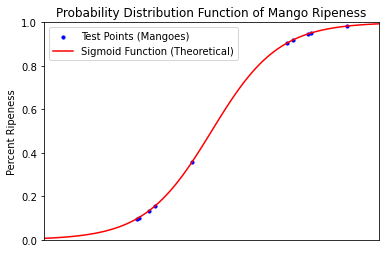

In [10]:
'''
Now let's create a matrix of the feature vectors we want to test, then test them!
'''

test_matrix = np.column_stack((test_avg_r, test_avg_g))
scores = []
probab = []
for i in range(np.shape(test_matrix)[0]):
    scores.append(logistic_regression.test(test_matrix[i, :])[0])   # just used for x position in graph
    probab.append(logistic_regression.test(test_matrix[i, :])[1])   # the actual ripeness or something


sorted_arrays =  sorted(zip(scores, probab, test_img_list))


sorted_scores, sorted_probab, sorted_img_list = zip(*sorted_arrays)   # sort lowest to highest for plotting

# print(sorted_probab)

plt.scatter(sorted_scores, sorted_probab, color='b', label='Test Points (Mangoes)', s=10)
plt.ylim(0,1)
plt.xlim(-5,5)

xvals = np.linspace(-5,5, 100)
f = logistic_regression.threshold(xvals)
plt.plot(xvals, f, color='r', label='Sigmoid Function (Theoretical)')
plt.title('Probability Distribution Function of Mango Ripeness')
plt.xticks([])
plt.ylabel('Percent Ripeness')
plt.legend()
# logistic_regression.test([0.9, 0.9])

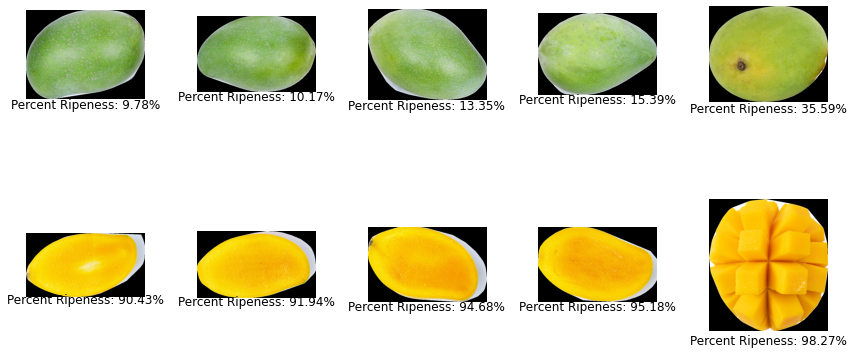

In [15]:
fig, axs = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    # Load the segmented mango image
    mango_image = sorted_img_list[i]

    # Determine the subplot position
    row = i // 5
    col = i % 5

    # Plot the segmented mango image
    axs[row, col].imshow(mango_image)
    axs[row, col].axis('off')

    # Add percent ripeness text
    ripeness_text = f'Percent Ripeness: {sorted_probab[i]*100:.2f}%'
    axs[row, col].text(0.5, -0.1, ripeness_text, transform=axs[row, col].transAxes, ha='center', fontsize=12)
plt.subplots_adjust(top=0.2)
plt.tight_layout()
plt.show()